# Assignment 5
## Part 2: Binocular Stereo
Mohammad Rashiqul Alam  
malam25@illinois.edu  

In [1]:
# Imports
import time, math, pathlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import uniform_filter  

### Window-Based Stereo Matching

In this section, I implement a simple window-based stereo matching algorithm for rectified stereo pairs. The goal is to compute a disparity map for each pixel in the reference (left) image by searching for the best matching window along the corresponding scanline in the right image.

#### Algorithm Overview

The stereo matching algorithm follows these steps:
- For each pixel in the left (reference) image, select a square window centered at that pixel.
- For each possible disparity (horizontal shift) up to a maximum value, compare the window in the left image to a shifted window in the right image using a matching cost function.
- Assign to each pixel the disparity value that yields the lowest matching cost.

I experiment with different window sizes, disparity ranges, and matching cost functions (SAD, SSD, NCC) to evaluate their effects on the quality and speed of the resulting disparity maps.

### Image Loading and Saving Utilities

To streamline image processing, I define utility functions for loading images in normalized grayscale format and for visualizing and saving results.  
- `load_gray(path)`: Loads an image from disk, converts it to grayscale, and normalizes pixel values to the range [0, 1].
- `show_and_save(img, title, fname)`: Displays a grayscale image with a title and saves it to the output directory for further analysis or reporting.

In [2]:
# Output directory for saving images
OUT_DIR = pathlib.Path("/home/rashiqul/workspace/ece549/Gen/a5")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def load_gray(path: str) -> np.ndarray:
    """
    Load an image from the given path and convert it to a normalized grayscale numpy array.

    Args:
        path (str): Path to the image file.

    Returns:
        np.ndarray: Grayscale image as float32 array with values in [0, 1].
    """
    # Open image, convert to grayscale, normalize to [0,1]
    img = Image.open(path).convert("L")
    return np.asarray(img, dtype=np.float32) / 255.0

In [4]:
def show_and_save(img: np.ndarray, title: str, fname: str):
    """
    Display a grayscale image with a title and save it to the output directory.

    Args:
        img (np.ndarray): Grayscale image array.
        title (str): Title for the plot.
        fname (str): Filename to save the image under OUT_DIR.
    """
    plt.figure()
    plt.imshow(img, cmap="gray")  # Show image in grayscale
    plt.axis("off")               # Hide axis
    plt.title(title)
    # Save figure to output directory, remove extra whitespace
    plt.savefig(OUT_DIR / fname, bbox_inches="tight", pad_inches=0)
    plt.close()

In [5]:
# Tsukuba (small; great for parameter sweeps)
tsuL = load_gray("tsukuba1.jpg")
tsuR = load_gray("tsukuba2.jpg")
tsuGT = load_gray("tsukuba_gt_first_pair.jpg")  # qualitative only

# Moebius (larger; use half-res or fewer settings to keep runtime sane)
moeL = load_gray("moebius1.png")
moeR = load_gray("moebius2.png")
moeGT = load_gray("moebius_gt_second_pair.png") # qualitative only

### Load Stereo Image Pairs

I load the left, right, and ground truth images for both the Tsukuba and Moebius datasets. All images are converted to normalized grayscale for processing.

In [6]:
# Load stereo image pairs and ground truth for Tsukuba and Moebius datasets
image_files = {
    "tsukuba": {
        "left": "tsukuba1.jpg",
        "right": "tsukuba2.jpg",
        "gt": "tsukuba_gt_first_pair.jpg"
    },
    "moebius": {
        "left": "moebius1.png",
        "right": "moebius2.png",
        "gt": "moebius_gt_second_pair.png"
    }
}

images = {}

for name, files in image_files.items():
    # For each dataset (tsukuba, moebius), load left, right, and ground truth images
    images[name] = {
        "left": load_gray(files["left"]),   # Load and normalize left image
        "right": load_gray(files["right"]), # Load and normalize right image
        "gt": load_gray(files["gt"])        # Load and normalize ground truth (qualitative only)
    }

### Implementation Details

The following helper functions are used in my implementation:

- `_pad_for_search(imgL, imgR, max_disp)`: Pads the right image to allow safe shifting during disparity search.
- `_box_sum(arr, win)`: Computes fast sliding window sums using a uniform filter.
- `compute_disparity(imgL, imgR, max_disp, win, metric)`: Computes the disparity map using the specified window size and matching metric.

The `compute_disparity` function supports three matching metrics:
- **SAD**: Sum of Absolute Differences
- **SSD**: Sum of Squared Differences
- **NCC**: Normalized Cross-Correlation

The output is a disparity map (with disparities in the range 0 to `max_disp`) and timing statistics.


In [7]:
def _pad_for_search(imgL: np.ndarray, imgR: np.ndarray, max_disp: int):
    """
    Pad the right image to allow safe shifting during stereo matching.

    Args:
        imgL (np.ndarray): Left (reference) image.
        imgR (np.ndarray): Right image.
        max_disp (int): Maximum disparity value to search.

    Returns:
        Tuple[np.ndarray, np.ndarray]: The left image (unchanged) and the right image padded on the left.
    """
    # Pad columns on the left of the right image so we can shift it up to max_disp pixels
    # This ensures that when searching for disparities, we do not run out of bounds
    return imgL, np.pad(imgR, ((0, 0), (max_disp, 0)), mode="edge")

In [8]:
def _box_sum(arr: np.ndarray, win: int) -> np.ndarray:
    """
    Compute the sum of values in a sliding window (box) of size win x win over the input array.

    Args:
        arr (np.ndarray): Input 2D array (image or cost map).
        win (int): Window size (must be odd).

    Returns:
        np.ndarray: Array of the same shape as input, where each element is the sum over a win x win window centered at that location.
    """
    # Use uniform_filter to efficiently compute the mean in a sliding window,
    # then multiply by the window area to get the sum.
    return uniform_filter(arr, size=win, mode="nearest") * (win * win)

In [9]:
def compute_disparity(imgL, imgR, max_disp, win=9, metric="SAD"):
    """
    Compute the disparity map for a rectified stereo pair using a window-based matching algorithm.

    Args:
        imgL (np.ndarray): Left (reference) grayscale image, normalized to [0, 1].
        imgR (np.ndarray): Right grayscale image, normalized to [0, 1].
        max_disp (int): Maximum disparity value to search (in pixels).
        win (int, optional): Window size (must be odd). Default is 9.
        metric (str, optional): Matching cost metric: "SAD", "SSD", or "NCC". Default is "SAD".

    Returns:
        Tuple[np.ndarray, Dict[str, float]]:
            - Disparity map (np.ndarray) with values in 0..max_disp.
            - Dictionary with timing statistics.
    """
    assert win % 2 == 1, "Window size must be odd."
    H, W = imgL.shape
    # Pad the right image so we can shift it safely for all disparities
    L, Rpad = _pad_for_search(imgL, imgR, max_disp)
    # Initialize cost volume: shape (num disparities, H, W)
    costs = np.full((max_disp+1, H, W), np.inf, dtype=np.float32)

    # Precompute left image statistics for NCC if needed
    if metric.upper() == "NCC":
        muL  = uniform_filter(L, size=win, mode="nearest")
        muL2 = uniform_filter(L*L, size=win, mode="nearest")
        sigL = np.maximum(muL2 - muL*muL, 1e-6)**0.5

    t0 = time.time()
    for d in range(max_disp+1):
        # Shift right image by d pixels to the right
        R = Rpad[:, d:d+W]
        if metric.upper() == "SAD":
            # Sum of Absolute Differences
            costs[d] = _box_sum(np.abs(L - R), win)
        elif metric.upper() == "SSD":
            # Sum of Squared Differences
            costs[d] = _box_sum((L - R)**2, win)
        elif metric.upper() == "NCC":
            # Normalized Cross-Correlation (similarity, so we negate for cost)
            muR  = uniform_filter(R, size=win, mode="nearest")
            muR2 = uniform_filter(R*R, size=win, mode="nearest")
            sigR = np.maximum(muR2 - muR*muR, 1e-6)**0.5
            cross = uniform_filter(L*R, size=win, mode="nearest")
            ncc   = (cross - muL*muR) / (sigL*sigR)  # similarity
            costs[d] = -ncc  # convert similarity to cost
        else:
            raise ValueError("metric must be SAD, SSD, or NCC")

    # For each pixel, select the disparity with the lowest cost
    disp = np.argmin(costs, axis=0).astype(np.float32)

    # Mask out invalid disparities near the left border (where disp > x)
    xs = np.arange(W)[None, :]
    disp[disp > xs] = 0.0

    return disp, {"elapsed_sec": time.time() - t0}

### Experiment 1: Disparity Maps for Tsukuba (Varying Window Size and Metric)

I compute disparity maps for the Tsukuba pair using different window sizes and matching metrics (SAD, SSD, NCC).  
This helps visualize the effect of window size and cost function on quality and runtime.

In [10]:
max_d_tsu = 24           # Maximum disparity for Tsukuba (chosen visually)
window_list = [5, 9, 15] # Window sizes to test
metrics = ["SAD", "SSD", "NCC"]
runtimes = []

tsuL, tsuR = images["tsukuba"]["left"], images["tsukuba"]["right"]

for w in window_list:
    for m in metrics:
        # Compute disparity map for each window size and metric
        disp, st = compute_disparity(tsuL, tsuR, max_disp=max_d_tsu, win=w, metric=m)
        # Visualize and save the normalized disparity map
        show_and_save(disp / max_d_tsu, f"Tsukuba {m} (w={w})", f"tsukuba_{m}_w{w}.png")
        # Record runtime for analysis
        runtimes.append((m, w, st["elapsed_sec"]))
runtimes

[('SAD', 5, 0.07428693771362305),
 ('SSD', 5, 0.04147505760192871),
 ('NCC', 5, 0.11105084419250488),
 ('SAD', 9, 0.0340876579284668),
 ('SSD', 9, 0.03253889083862305),
 ('NCC', 9, 0.09241223335266113),
 ('SAD', 15, 0.03815460205078125),
 ('SSD', 15, 0.03238987922668457),
 ('NCC', 15, 0.08240127563476562)]

### Inline Best Disparity Results

Display the best disparity maps for Tsukuba and Moebius using recommended parameters. These figures will appear inline for PDF export and qualitative comparison.

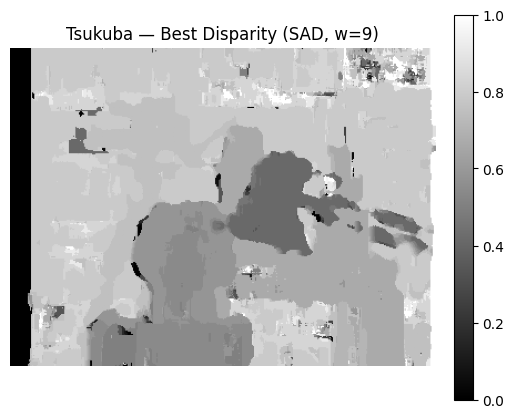

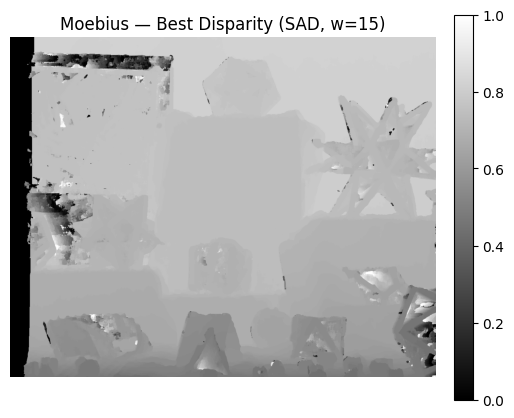

In [11]:
# Heuristics: Tsukuba -> small disparity range, window=9, SAD
max_d_tsu = 24
best_tsu_disp, _ = compute_disparity(tsuL, tsuR, max_disp=max_d_tsu, win=9, metric="SAD")

# Moebius -> larger disparity range, window=15, SAD
max_d_moe = 96
best_moe_disp, _ = compute_disparity(moeL, moeR, max_disp=max_d_moe, win=15, metric="SAD")

# Show Tsukuba best disparity map inline
plt.figure(figsize=(6,5))
plt.title("Tsukuba — Best Disparity (SAD, w=9)")
im = plt.imshow(best_tsu_disp / max_d_tsu, cmap="gray")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

# Show Moebius best disparity map inline
plt.figure(figsize=(6,5))
plt.title("Moebius — Best Disparity (SAD, w=15)")
im = plt.imshow(best_moe_disp / max_d_moe, cmap="gray")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

### Qualitative Comparison to Ground Truth (GT) and Mean Absolute Error (MAE)

I compare our best disparity predictions to the ground truth (GT) maps for both Tsukuba and Moebius.  
A scalar scale factor α is computed to best align the predicted disparity to the GT (using least-squares on valid pixels).  
I report the Mean Absolute Error (MAE) after alignment and show side-by-side plots of GT, prediction, and the absolute error map.

In [12]:
def align_scale_and_mae(pred_disp, gt_img, valid_thresh=1e-6):
    """
    Aligns a scalar α to minimize || pred - α*gt ||_2 over valid pixels (gt > 0),
    then returns α, MAE (in 'disparity units' of pred), and a diff image.

    Args:
        pred_disp (np.ndarray): Predicted disparity map.
        gt_img (np.ndarray): Ground truth disparity map (normalized to [0, 1]).
        valid_thresh (float, optional): Threshold for valid GT pixels. Default is 1e-6.

    Returns:
        Tuple[float, float, np.ndarray]:
            - alpha: scale factor aligning GT to prediction.
            - mae: mean absolute error after alignment.
            - diff: difference image (pred_disp - alpha * gt_img).
    """
    # Convert ground truth to float (should be in [0, 1])
    gt = gt_img.astype(np.float32)

    # Create mask for valid pixels (where GT > 0)
    mask = gt > 0.0

    # If no valid pixels, return defaults
    if not np.any(mask):
        return 1.0, np.nan, np.zeros_like(pred_disp)

    # Solve for alpha using least squares: minimize || pred - α*gt ||^2
    num = (pred_disp[mask] * gt[mask]).sum()
    den = (gt[mask] * gt[mask]).sum() + 1e-8  # avoid division by zero
    alpha = num / den

    # Compute difference image and mean absolute error
    diff = pred_disp - alpha * gt
    mae = np.mean(np.abs(diff[mask]))
    return alpha, mae, diff

[Tsukuba] scale α = 32.440,  MAE (post-align) = 7.650 disparity-units


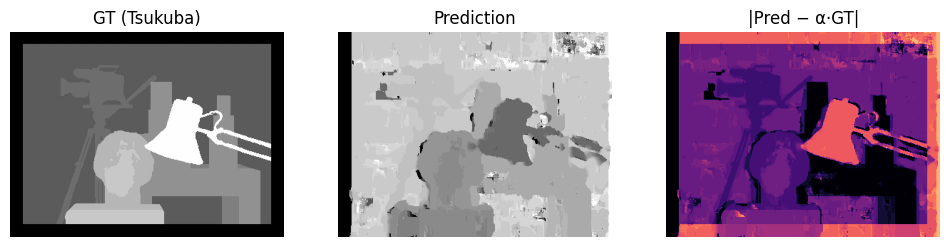

In [13]:
# Tsukuba qualitative comparison to ground truth
alpha_tsu, mae_tsu, diff_tsu = align_scale_and_mae(best_tsu_disp, tsuGT)
# Compute scale factor alpha to best align prediction to GT, and get MAE and difference image

print(f"[Tsukuba] scale α = {alpha_tsu:.3f},  MAE (post-align) = {mae_tsu:.3f} disparity-units")
# Print the scale factor and mean absolute error after alignment

# Show ground truth disparity map
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("GT (Tsukuba)")
plt.imshow(tsuGT, cmap="gray")
plt.axis("off")  

 # Show normalized prediction
plt.subplot(1,3,2); plt.title("Prediction")
plt.imshow(best_tsu_disp / (best_tsu_disp.max()+1e-6), cmap="gray") 
plt.axis("off") 

# Show absolute error map
plt.subplot(1,3,3); plt.title("|Pred − α·GT|")
plt.imshow(np.abs(diff_tsu), cmap="magma")
plt.axis("off")  

# Display all plots
plt.show()  

[Moebius] scale α = 128.714,  MAE (post-align) = 25.290 disparity-units


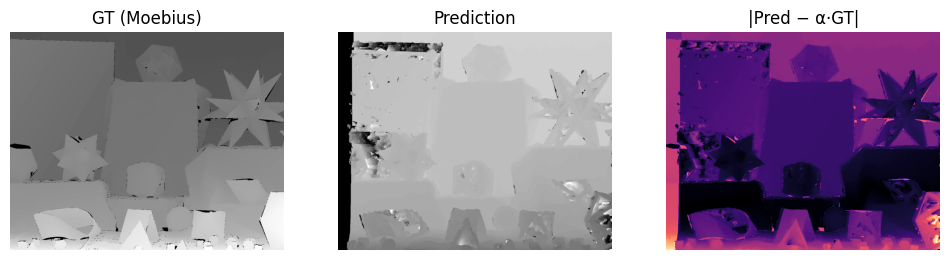

In [14]:
# Moebius qualitative comparison to ground truth
# Compute scale factor alpha to best align prediction to GT, and get MAE and difference image
alpha_moe, mae_moe, diff_moe = align_scale_and_mae(best_moe_disp, moeGT)

# Print the scale factor and mean absolute error after alignment
print(f"[Moebius] scale α = {alpha_moe:.3f},  MAE (post-align) = {mae_moe:.3f} disparity-units")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("GT (Moebius)")
plt.imshow(moeGT, cmap="gray"); plt.axis("off")  # Show ground truth disparity map

# Show normalized prediction
plt.subplot(1,3,2); plt.title("Prediction")
plt.imshow(best_moe_disp / (best_moe_disp.max()+1e-6), cmap="gray") 
plt.axis("off")  

# Show absolute error map
plt.subplot(1,3,3); plt.title("|Pred − α·GT|")
plt.imshow(np.abs(diff_moe), cmap="magma")
plt.axis("off")  

# Display all plots
plt.show() 

### Experiment 2: Moebius Disparity Map at Half Resolution

To reduce computation time, I then downsample the Moebius images by half and compute the disparity map using a larger window and the SAD metric.

In [15]:
def half(img: np.ndarray) -> np.ndarray:
    """
    Downsample an image by a factor of 2 using bilinear interpolation.

    Args:
        img (np.ndarray): Input grayscale image with values in [0, 1].

    Returns:
        np.ndarray: Downsampled image (half the width and height), values in [0, 1].
    """
    # Convert image to uint8 for PIL compatibility
    img_uint8 = (img * 255).astype(np.uint8)
    # Resize image to half its original size using bilinear interpolation
    img_half = Image.fromarray(img_uint8).resize(
        (img.shape[1] // 2, img.shape[0] // 2), Image.Resampling.BILINEAR
    )
    # Convert back to float32 in [0, 1] range
    return np.asarray(img_half, dtype=np.float32) / 255.0

In [16]:
moeL2, moeR2 = half(images["moebius"]["left"]), half(images["moebius"]["right"])
# Downsample Moebius left and right images by half for faster computation

disp_moe, st_moe = compute_disparity(moeL2, moeR2, max_disp=64, win=15, metric="SAD")
# Compute disparity map for half-resolution Moebius images using SAD metric and a large window

show_and_save(disp_moe / 64.0, "Moebius half-res SAD w=15", "moebius_half_SAD_w15.png")
# Visualize and save the normalized disparity map for Moebius

st_moe  # Display timing statistics for this experiment

{'elapsed_sec': 0.5468297004699707}

### Runtime Analysis: Tsukuba Stereo Matching

To better understand the computational cost of different stereo matching settings, I summarize the runtime for each combination of window size and matching metric on the Tsukuba dataset. The following bar chart visualizes how the choice of window size and cost function (SAD, SSD, NCC) affects processing tim

Metric | Window | Seconds
--------------------------
 SAD   |      5 |   0.074
 SSD   |      5 |   0.041
 NCC   |      5 |   0.111
 SAD   |      9 |   0.034
 SSD   |      9 |   0.033
 NCC   |      9 |   0.092
 SAD   |     15 |   0.038
 SSD   |     15 |   0.032
 NCC   |     15 |   0.082


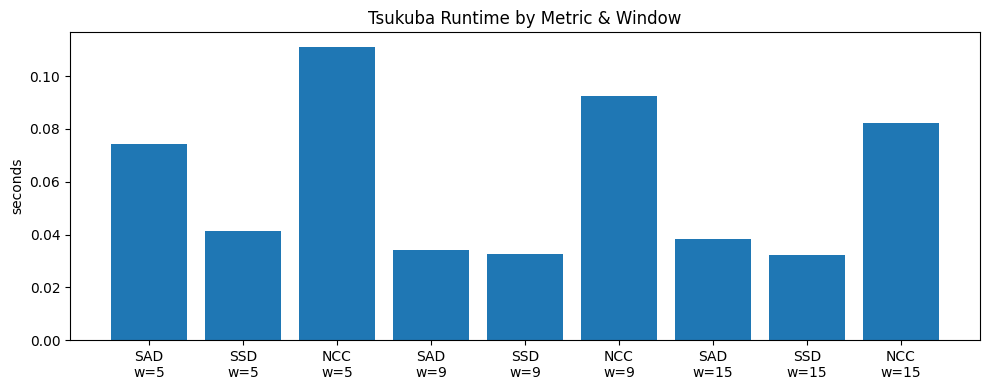

In [18]:
# Print a neat table of runtimes collected during parameter sweep
print("Metric | Window | Seconds")
print("--------------------------")
for m, w, s in runtimes:
    print(f"{m:>4}   | {w:>6} | {s:7.3f}")

# Bar chart (Matplotlib, no seaborn)
labels = [f"{m}\nw={w}" for (m, w, _) in runtimes]
values = [s for (_, _, s) in runtimes]

plt.figure(figsize=(10,4))
plt.title("Tsukuba Runtime by Metric & Window")
plt.bar(range(len(values)), values)
plt.xticks(range(len(values)), labels, rotation=0)
plt.ylabel("seconds")
plt.tight_layout()
plt.show()

### Experiment 3: Runtime Summary

Summarize the runtime for each combination of window size and metric on the Tsukuba dataset.

In [17]:
# Print runtime for each metric and window size combination
for m, w, s in runtimes:
    print(f"{m:>3}  w={w:>2}  {s:.3f}s")

SAD  w= 5  0.074s
SSD  w= 5  0.041s
NCC  w= 5  0.111s
SAD  w= 9  0.034s
SSD  w= 9  0.033s
NCC  w= 9  0.092s
SAD  w=15  0.038s
SSD  w=15  0.032s
NCC  w=15  0.082s
